# The Columbia has a pulse

Every adult salmon that swims up the Columbia is counted — by a person at a window beside
each dam's fish ladder, every day, at Bonneville since 1938. This notebook joins those
counts to the river that carries them: flow, spill and temperature from the same dams,
through the same five-line omnisea pipeline as any tide gauge or weather station.

The payoff is a measurement you can't make from one station: the 2024 sockeye run arrives
at Rock Island Dam as a copy of the Bonneville wave, shifted by a measurable number of
days — the run's **upstream swimming speed**, extracted from two count sheets.

Everything ran live against DART (Columbia Basin Research, University of Washington);
every number in the prose is printed by a cell.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omnisea

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (11, 3.4)

SEASON = ("2024-05-01", "2024-09-30")
print(f"omnisea {omnisea.__version__} — stations by id, no coordinates anywhere below")

omnisea 0.1.0 — stations by id, no coordinates anywhere below


## 1. Fetch dams by name

`BON` is Bonneville, river km 235; `RIS` is Rock Island, ~470 river km further up, on the
sockeye's road to the Wenatchee. `stations=` resolves each id through DART's own catalogue —
and the citation block below prints because every `fetch()` shows its sources.

In [2]:
tree = omnisea.fetch(
    stations={"dart_passage": ["BON", "RIS"], "dart_river": "BON"},
    time=SEASON,
)
print()
print(omnisea.describe(tree)[["node", "station_name", "n_time"]].to_string(index=False))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T12:42:03+00:00 from 2 source(s) across 2 station(s), covering 2024-05-01 to 2024-09-30.

  Columbia Basin Research (University of Washington) — DART — dart_passage (2 station(s), 2024-05-01 to 2024-09-30): Bonneville Dam (BON), Rock Island Dam (RIS). Licence: Public data compiled by Columbia Basin Research from USACE, PUD and agency records; credit Columbia Basin Research, University of Washington. Terms: https://www.cbr.washington.edu/dart
  Columbia Basin Research (University of Washington) — DART — dart_river (1 station(s), 2024-05-01 to 2024-09-30): Bonneville Dam (BON). Licence: Public data compiled by Columbia Basin Research from USACE, PUD and agency records; credit Columbia Basin Research, University of Washington. Terms: https://www.cbr.washington.edu/dart


(saved at tree.attrs["citation"]; omnisea.citation(tree) re-renders it any time)

                          node    station_name  n_time
     /in_situ/fish_passage/BON  Bonneville Dam     153
     /in_situ/fish_passage/RIS Rock Island Dam     153
/in_situ/hydrometric_daily/BON  Bonneville Dam     153


Fish land under their own branch — `in_situ/fish_passage` — because a
count is not a sensor reading: it is a day's total, `cell_methods: "time: sum"`, under plain
English names. There is no CF standard name for a salmon, and the variable attributes say so
rather than pretending.

## 2. One daily matrix: fish and river together

In [3]:
X = omnisea.align(tree, freq="1D")
species = [c for c in X.columns if c.split("@")[0] in
           ("chinook", "sockeye", "steelhead", "coho", "shad") and "@BON" in c]
print(f"{X.shape[0]} days x {X.shape[1]} columns\n")
totals = X[species].sum().astype(int).sort_values(ascending=False)
totals.index = [i.split("@")[0] for i in totals.index]
print("season totals at Bonneville:")
print(totals.to_string())

153 days x 27 columns

season totals at Bonneville:
sockeye      755909
chinook      605177
steelhead    173966
coho         143767


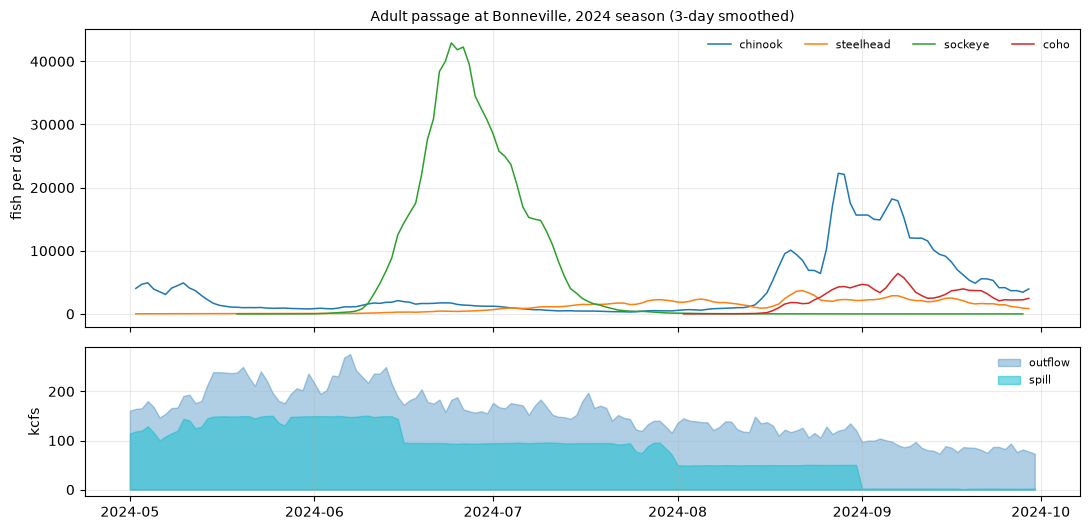

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for c in species:
    ax1.plot(X.index, X[c].rolling(3, center=True).mean(), lw=1.1,
             label=c.split("@")[0])
ax1.set_ylabel("fish per day"); ax1.legend(frameon=False, ncols=5, fontsize=8)
ax1.set_title("Adult passage at Bonneville, 2024 season (3-day smoothed)", fontsize=10)
ax1.grid(alpha=0.25)
ax2.fill_between(X.index, X["river_discharge"], color="tab:blue", alpha=0.35,
                 label="outflow")
ax2.fill_between(X.index, X["spill_discharge"], color="tab:cyan", alpha=0.55,
                 label="spill")
ax2.set_ylabel("kcfs"); ax2.legend(frameon=False, fontsize=8); ax2.grid(alpha=0.25)
fig.tight_layout()

Each species is a wave with its own calendar: shad in June on the tail of
the freshet, sockeye cresting through early July as the spill winds down, steelhead and fall
Chinook building as the water warms. These are migrations, visible as time series.

## 3. The same wave, twice

Sockeye bound for the Wenatchee basin pass Bonneville first and Rock Island roughly 470
river kilometres later. If the run holds together, Rock Island's count sheet should be
Bonneville's — delayed.

2024 sockeye: 755,909 counted at Bonneville, 728,852 at Rock Island


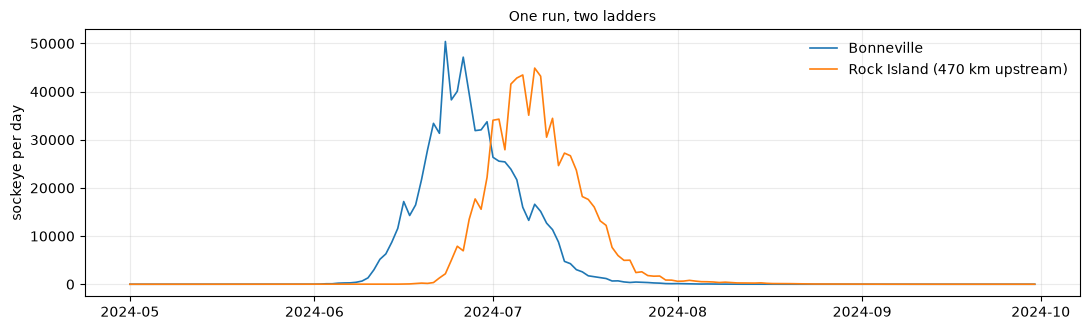

In [5]:
bon = X["sockeye@BON"].fillna(0)
ris = X["sockeye@RIS"].fillna(0)
print(f"2024 sockeye: {int(bon.sum()):,} counted at Bonneville, "
      f"{int(ris.sum()):,} at Rock Island")

fig, ax = plt.subplots()
ax.plot(X.index, bon, lw=1.2, label="Bonneville")
ax.plot(X.index, ris, lw=1.2, label="Rock Island (470 km upstream)")
ax.set_ylabel("sockeye per day"); ax.legend(frameon=False)
ax.set_title("One run, two ladders", fontsize=10); ax.grid(alpha=0.25)
fig.tight_layout()

## 4. Measure the swim

Slide Rock Island's series back one day at a time and ask when it lines up best with
Bonneville's. The lag at peak correlation is the run's median travel time; distance over
time is speed.

peak alignment at 11 days (r = 0.981)
~470 river km / 11 days = 43 km per day upstream, against the current, through eight ladders


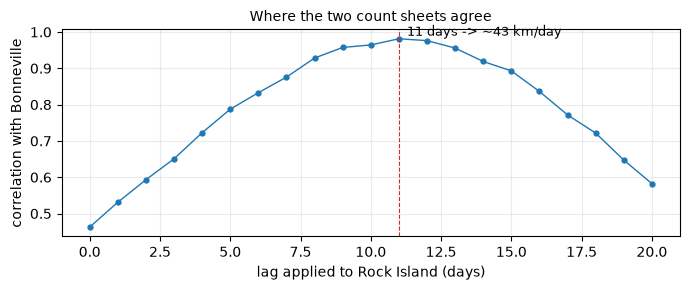

In [6]:
lags = range(0, 21)
r = pd.Series({k: bon.corr(ris.shift(-k)) for k in lags})
best = int(r.idxmax())
print(f"peak alignment at {best} days (r = {r.max():.3f})")
print(f"~470 river km / {best} days = {470 / best:.0f} km per day upstream, "
      "against the current, through eight ladders")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(r.index, r.values, marker="o", ms=3.5, lw=1)
ax.axvline(best, color="tab:red", lw=0.8, ls="--")
ax.annotate(f"  {best} days -> ~{470 / best:.0f} km/day", (best, r.max()),
            fontsize=9, va="bottom")
ax.set_xlabel("lag applied to Rock Island (days)"); ax.set_ylabel("correlation with Bonneville")
ax.set_title("Where the two count sheets agree", fontsize=10); ax.grid(alpha=0.25)
fig.tight_layout()

Radio-tagging studies put adult sockeye at roughly 40–55 km/day on the
mainstem Columbia. Two windows, two clipboards and a cross-correlation land in the same
range — the kind of consistency check that says the join, the dates and the counts are all
holding together.

## 5. What travels with the fish

The river variables came along in the same matrix, so the season's structure is one
`corr()` away.

In [7]:
conditions = X[["sockeye@BON", "river_discharge", "spill_discharge",
                "water_temperature@BON"]].dropna()
print(f"{len(conditions)} days with fish and river both reported\n")
print(conditions.corr()["sockeye@BON"].drop("sockeye@BON").round(2).to_string())

131 days with fish and river both reported

river_discharge          0.21
spill_discharge          0.20
water_temperature@BON   -0.20


Correlation is a season-shape statement, not a mechanism: the sockeye
crest as the spill program winds down and the water warms past 18 °C, because all three
follow the calendar. The matrix is where a real analysis would start — lagged flows,
temperature thresholds, year-over-year comparisons back to 1938.

## 6. Cite the counters

Someone sat at a window and counted 26,000 sockeye in a day. The attribution already
printed at fetch time and is stamped on the tree; here is the block again, deliberately.

In [8]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T12:42:03+00:00 from 2 source(s) across 2 station(s), covering 2024-05-01 to 2024-09-30.

  Columbia Basin Research (University of Washington) — DART — dart_passage (2 station(s), 2024-05-01 to 2024-09-30): Bonneville Dam (BON), Rock Island Dam (RIS). Licence: Public data compiled by Columbia Basin Research from USACE, PUD and agency records; credit Columbia Basin Research, University of Washington. Terms: https://www.cbr.washington.edu/dart
  Columbia Basin Research (University of Washington) — DART — dart_river (1 station(s), 2024-05-01 to 2024-09-30): Bonneville Dam (BON). Licence: Public data compiled by Columbia Basin Research from USACE, PUD and agency records; credit Columbia Basin Research, University of Washington. Terms: https://www.cbr.washington.edu/dart


## Recap

* `stations={"dart_passage": ["BON", "RIS"], "dart_river": "BON"}` — dams by name, no
  coordinates, citation printed on arrival.
* Fish counts are first-class series: day totals under plain names, beside flow, spill and
  temperature in one `align(freq="1D")` matrix.
* Two count sheets 470 km apart measure the run itself: an 11-day shift at r ≈ 0.98,
  ~43 km/day upstream — consistent with tagging studies.
* `citation(tree)` credits Columbia Basin Research and the University of Washington.

The other notebooks walk tides, waves and weather; this one is here because a data library
for the Pacific Northwest that cannot see the salmon is missing the point.